# 3D cartonization solver: guided proof

This notebook walks through the production `solve_order()` flow using masked iHub v2 orders. It is designed to answer four practical questions:

1. Does the solver enforce weight, rotation, fill-cap, and carton-buffer constraints?
2. Can it explain why cartons and placements were accepted or rejected?
3. When does it match or improve on the current iHub result?
4. Does exact Best close the heuristic gaps, and when does its time budget fall back?

The examples are followed by a reproducible 2,000-order benchmark. A different geometric arrangement is not automatically wrong: feasibility and constraint compliance come first, then carton count, largest carton size, total carton volume, and latency.

## Units

- Item and carton dimensions: **millimetres (mm)**
- Buffer and packed XYZ coordinates: **millimetres (mm)**
- Derived volumes: **cubic millimetres (mm³)**
- Item and carton weight: **kilograms (kg)**

These units match the source dataset and the solver contract, so no conversion is required. All order identifiers and item codes in this development dataset are masked.

In [1]:
import json
import math
import statistics
from pathlib import Path
import sys

from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from bin_packing_3d import display_result, display_table, solve_order

## 1. Inputs: candidate cartons

These are the real masked iHub v2 candidate cartons in millimetres. The package normalizes them from smallest to largest.

In [2]:
DATA_PATH = ROOT / 'data' / 'raw' / 'data_samples_v2.json'
with DATA_PATH.open(encoding='utf-8') as file:
    ihub_records = {record['input']['OrderId']: record for record in json.load(file)}

catalogue_source = next(iter(ihub_records.values()))['input']
boxes = [dict(box) for box in catalogue_source['Bins']['BinsList']]
box_rows = [
    {
        'Code': box['Code'], 'Length (mm)': box['Length'],
        'Width (mm)': box['Width'], 'Height (mm)': box['Height'],
        'Max weight (kg)': box['MaxWeight'],
    }
    for box in boxes
]
display_table(box_rows)

Code,Length (mm),Width (mm),Height (mm),Max weight (kg)
Box2,270.0,170.0,115.0,20
Box4,340.0,260.0,150.0,20
Box5,340.0,260.0,235.0,20
Box6,340.0,260.0,280.0,20
Box8,290.0,180.0,280.0,20
Box9,440.0,345.0,280.0,20


## 2. User-visible packing rules

The configurable rules are passed explicitly through the `solve_order()` signature. The values below come from the same iHub request: a 6 mm height buffer, 100% maximum fill for up to six physical items, and a 70% cap above six items. `logs=True` exposes screening and placement decisions; `visualize=True` draws only the independently validated result.

In [3]:
source_parameters = catalogue_source['Bins']['Parameters']
source_buffer = source_parameters['BinBuffer']
high_item_count_threshold = source_parameters['BinMaxFillCheckMinItemQty']
high_item_count_max_fill_pct = source_parameters['BinMaxFillPct']
max_fill_pct = 100
bin_buffer = {
    'length': source_buffer['Length'],
    'width': source_buffer['Width'],
    'height': source_buffer['Height'],
}
display_table([{
    'Mode': 'fast',
    'Item threshold': high_item_count_threshold,
    'High-count max fill (%)': high_item_count_max_fill_pct,
    'General max fill (%)': max_fill_pct,
    'Buffer L (mm)': bin_buffer['length'],
    'Buffer W (mm)': bin_buffer['width'],
    'Buffer H (mm)': bin_buffer['height'],
}])

Mode,Item threshold,High-count max fill (%),General max fill (%),Buffer L (mm),Buffer W (mm),Buffer H (mm)
fast,6,70,100,0,0,6


## 3. Full solver flow: order 80 → one Box4

Order 80 demonstrates the complete production path: normalize inputs, expand quantities, apply the 70% cap, subtract the 6 mm height buffer, screen cartons, search XYZ placements, independently validate the plan, calculate metrics, and render the result. It contains eight physical items across seven SKU lines. The detailed log shows actual rejection reasons and final item-to-carton assignments; Fast, Best, and iHub all use one Box4.

In [4]:
source_order_80 = ihub_records[80]['input']
items_order_80 = [dict(item) for item in source_order_80['Items']['ItemsList']]
order_80 = {
    'OrderId': source_order_80['OrderId'],
    'OrderNo': source_order_80['OrderNo'],
    'Items': items_order_80,
}
item_rows_80 = [
    {
        **item, 'Length (mm)': item['Length'], 'Width (mm)': item['Width'],
        'Height (mm)': item['Height'], 'Weight (kg)': item['Weight'],
    }
    for item in items_order_80
]
display_table(item_rows_80, [
    'Code', 'Length (mm)', 'Width (mm)', 'Height (mm)', 'Weight (kg)',
    'Quantity', 'VerticalRotation', 'UOM',
])

Code,Length (mm),Width (mm),Height (mm),Weight (kg),Quantity,VerticalRotation,UOM
30,245,40,125.0,0.2,1,1,BOX
9,255,40,192.0,1.25,1,1,SET
95,70,70,60.0,0.1458,1,1,EA
103,55,50,175.0,0.2125,2,1,EA
2,110,65,110.0,0.2292,1,1,BOX
332,60,60,120.0,0.2083,1,1,EA
73,50,50,90.0,0.0722,1,1,EA


=== 3D packing log ===

Order summary
Metric                 | Value         
-----------------------+---------------
Physical items         | 8             
Total item volume      | 5,883,400 mm^3
Total item weight      | 2.5305 kg     
Effective maximum fill | 70%           

Candidate cartons (smallest external volume first)
Carton | External mm^3 | Usable L x W x H (mm) | Fill cap mm^3 | Result                                        
-------+---------------+-----------------------+---------------+-----------------------------------------------
Box2   | 5,278,500     | 270 x 170 x 109       | 3,502,170     | REJECTED by volume: 5,883,400 > 3,502,170 mm^3
Box4   | 13,260,000    | 340 x 260 x 144       | 8,910,720     | PASSED screen; evaluated during 3D search     
Box8   | 14,616,000    | 290 x 180 x 274       | 10,011,960    | PASSED screen; evaluated during 3D search     
Box5   | 20,774,000    | 340 x 260 x 229       | 14,170,520    | PASSED screen; evaluated during 3D search    

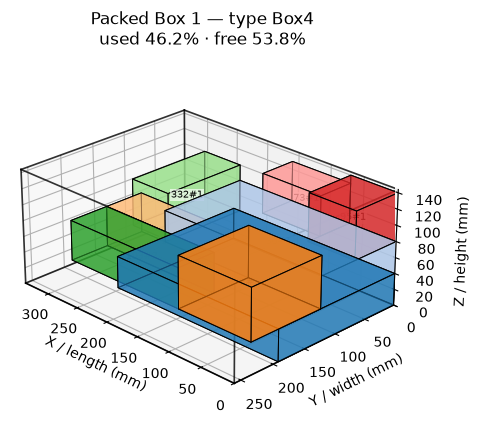

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,fast_fit,1,1,carton-1,Box4,8,46.22,1.056,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box4,9#1,255.0,192.0,40.0,0.0,0.0,0.0,1958400.0
carton-1,Box4,30#1,245.0,125.0,40.0,0.0,0.0,40.0,1225000.0
carton-1,Box4,2#1,110.0,110.0,65.0,0.0,125.0,40.0,786500.0
carton-1,Box4,103#1,175.0,55.0,50.0,110.0,125.0,40.0,481250.0
carton-1,Box4,103#2,175.0,55.0,50.0,110.0,180.0,40.0,481250.0
carton-1,Box4,332#1,60.0,120.0,60.0,245.0,0.0,40.0,432000.0
carton-1,Box4,95#1,70.0,70.0,60.0,0.0,0.0,80.0,294000.0
carton-1,Box4,73#1,90.0,50.0,50.0,70.0,0.0,80.0,225000.0


In [5]:
order_80_result = solve_order(
    order_80,
    boxes,
    mode='fast',
    high_item_count_threshold=high_item_count_threshold,
    high_item_count_max_fill_pct=high_item_count_max_fill_pct,
    max_fill_pct=max_fill_pct,
    bin_buffer=bin_buffer,
    dimension_unit='mm',
    logs=True,
    visualize=True,
)
display_result(order_80_result)

## 4. Constraint proof: upright-only items in order 285

This is masked iHub v2 order 285. It contains eight varied but relatively small items. Four source lines, representing five physical units, are upright-only (`VerticalRotation = 0`), while the remaining items may be laid down. With the source rules enforced, Best and iHub select one Box8 at about 46.7% usable fill.

In [6]:
source_order_285 = ihub_records[285]['input']
items_order_285 = [dict(item) for item in source_order_285['Items']['ItemsList']]
order_285 = {
    'OrderId': source_order_285['OrderId'],
    'OrderNo': source_order_285['OrderNo'],
    'Items': items_order_285,
}
item_rows_285 = [
    {
        **item, 'Length (mm)': item['Length'], 'Width (mm)': item['Width'],
        'Height (mm)': item['Height'], 'Weight (kg)': item['Weight'],
    }
    for item in items_order_285
]
display_table(item_rows_285, [
    'Code', 'Length (mm)', 'Width (mm)', 'Height (mm)', 'Weight (kg)',
    'Quantity', 'VerticalRotation', 'UOM',
])

Code,Length (mm),Width (mm),Height (mm),Weight (kg),Quantity,VerticalRotation,UOM
94,40,40,130.0,0.1143,1,1,EA
136,80,80,210.0,0.65,1,0,EA
95,70,70,60.0,0.1458,1,1,EA
327,100,70,160.0,0.2667,1,1,EA
375,70,70,200.0,0.6667,1,0,EA
188,70,70,142.0,0.4167,2,0,EA
138,80,80,210.0,0.65,1,0,EA


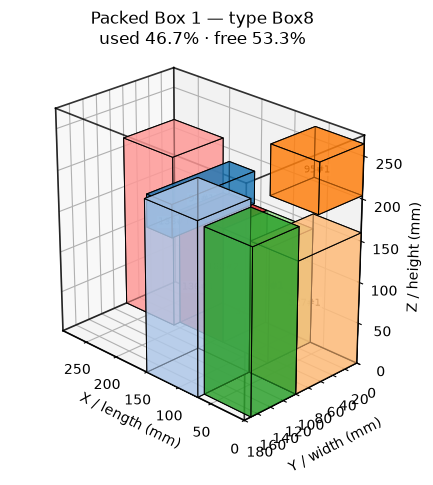

Status,Strategy,Total cartons,Carton number,Carton,Box type,Item qty,Usable fill (%),Runtime (ms),Valid
success,best_fit,1,1,carton-1,Box8,8,46.72,44.012,True


Carton,Box type,Item,Packed L (mm),Packed W (mm),Packed H (mm),X (mm),Y (mm),Z (mm),Volume (mm^3)
carton-1,Box8,94#1,40.0,130.0,40.0,160.001,0.0,144.001,208000.0
carton-1,Box8,136#1,80.0,80.0,210.0,70.0,100.0,0.0,1344000.0
carton-1,Box8,95#1,70.0,70.0,60.0,0.0,0.0,204.001,294000.0
carton-1,Box8,327#1,70.0,100.0,160.0,0.0,0.0,0.0,1120000.0
carton-1,Box8,375#1,70.0,70.0,200.0,0.0,100.0,0.0,980000.0
carton-1,Box8,188#1,70.0,70.0,142.0,70.0,0.0,0.0,695800.0
carton-1,Box8,188#2,70.0,70.0,142.0,140.0,0.0,0.0,695800.0
carton-1,Box8,138#1,80.0,80.0,210.0,210.0,0.0,0.0,1344000.0


In [7]:
order_285_result = solve_order(
    order_285,
    boxes,
    mode='best',
    high_item_count_threshold=high_item_count_threshold,
    high_item_count_max_fill_pct=high_item_count_max_fill_pct,
    max_fill_pct=max_fill_pct,
    bin_buffer=bin_buffer,
    dimension_unit='mm',
    visualize=True,
)
display_result(order_285_result)

### Why `VerticalRotation` changes the carton choice

The next result is a deliberately invalid counterfactual: it changes every item to `VerticalRotation = 1`, including units that the source says must remain upright. This is useful for demonstrating the rule, but it must not be treated as a valid recommendation for the real order.

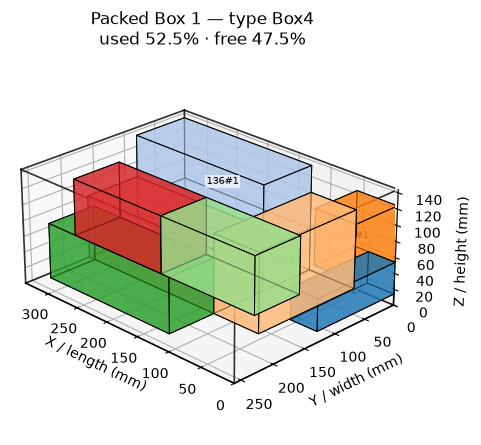

Scenario,Box type,Item qty,Usable fill (%),Valid for source order
Respect source rotation rules,Box8,8,46.72,YES
Ignore upright-only restrictions,Box4,8,52.49,NO — 5 upright-only units are laid down


Item,Required source orientation (mm),Counterfactual packed orientation (mm),Rule violation
136#1,80 × 80 × 210,210 × 80 × 80,Upright-only item laid down
375#1,70 × 70 × 200,200 × 70 × 70,Upright-only item laid down
188#1,70 × 70 × 142,142 × 70 × 70,Upright-only item laid down
188#2,70 × 70 × 142,142 × 70 × 70,Upright-only item laid down
138#1,80 × 80 × 210,210 × 80 × 80,Upright-only item laid down


In [8]:
items_285_ignore_upright = [
    {**item, 'VerticalRotation': 1} for item in items_order_285
]
order_285_ignore_upright = {**order_285, 'Items': items_285_ignore_upright}
order_285_ignore_upright_result = solve_order(
    order_285_ignore_upright,
    boxes,
    mode='best',
    high_item_count_threshold=high_item_count_threshold,
    high_item_count_max_fill_pct=high_item_count_max_fill_pct,
    max_fill_pct=max_fill_pct,
    bin_buffer=bin_buffer,
    dimension_unit='mm',
    visualize=True,
)

display_table([
    {
        'Scenario': 'Respect source rotation rules',
        'Box type': order_285_result.packed_boxes[0].box_code,
        'Item qty': order_285_result.metrics.packed_item_count,
        'Usable fill (%)': round(order_285_result.metrics.boxes[0].usable_utilization_pct, 2),
        'Valid for source order': 'YES',
    },
    {
        'Scenario': 'Ignore upright-only restrictions',
        'Box type': order_285_ignore_upright_result.packed_boxes[0].box_code,
        'Item qty': order_285_ignore_upright_result.metrics.packed_item_count,
        'Usable fill (%)': round(order_285_ignore_upright_result.metrics.boxes[0].usable_utilization_pct, 2),
        'Valid for source order': 'NO — 5 upright-only units are laid down',
    },
])

source_item_by_code_285 = {item['Code']: item for item in items_order_285}
ignored_rotation_rows = []
for placement in order_285_ignore_upright_result.placements:
    source_item = source_item_by_code_285[placement.item_code]
    if source_item['VerticalRotation'] == 0:
        ignored_rotation_rows.append({
            'Item': placement.item_instance_id,
            'Required source orientation (mm)': f"{source_item['Length']:g} × {source_item['Width']:g} × {source_item['Height']:g}",
            'Counterfactual packed orientation (mm)': f"{placement.orientation.length:g} × {placement.orientation.width:g} × {placement.orientation.height:g}",
            'Rule violation': 'Upright-only item laid down',
        })
display_table(ignored_rotation_rows)

# 5. Fast, Best, and iHub: evidence-based comparisons

Fast is the former Best heuristic: it scores feasible 3D placements and tries promising fixed-carton combinations without backtracking. The original weaker First Fit implementation is no longer a production mode. Best retains Fast as a validated fallback, then uses an exact CP-SAT feasibility model to test carton combinations in objective order: fewer cartons first, then the smaller largest carton, then lower total external carton volume. It reports whether optimality was proven or the time budget returned Fast. Solver rows marked PASS were independently validated for accounting, rotation, boundaries, collision, weight, and fill. The iHub dataset does not provide XYZ coordinates, so its displayed rule check covers the reported fill cap only. All latency values shown below are warm measurements.

In [9]:
def compare_order(order_id):
    record = ihub_records[order_id]
    source = record['input']
    items = [dict(item) for item in source['Items']['ItemsList']]
    boxes_for_order = [dict(box) for box in source['Bins']['BinsList']]
    order = {
        'OrderId': source['OrderId'],
        'OrderNo': source['OrderNo'],
        'Items': items,
    }

    parameters = source['Bins']['Parameters']
    buffer = parameters['BinBuffer']
    threshold = parameters['BinMaxFillCheckMinItemQty']
    high_count_fill = parameters['BinMaxFillPct']
    physical_item_count = sum(item['Quantity'] for item in items)
    fill_cap = high_count_fill if physical_item_count > threshold else 100
    buffer_by_axis = {
        'length': buffer['Length'],
        'width': buffer['Width'],
        'height': buffer['Height'],
    }

    def run(mode):
        return solve_order(
            order,
            boxes_for_order,
            mode=mode,
            high_item_count_threshold=threshold,
            high_item_count_max_fill_pct=high_count_fill,
            max_fill_pct=100,
            bin_buffer=buffer_by_axis,
        )

    fast = run('fast')
    best = run('best')
    box_by_code = {box['Code']: box for box in boxes_for_order}
    ihub_packed = record['output']['Data']['BinsPacked']

    def external_volume(code):
        box = box_by_code[code]
        return box['Length'] * box['Width'] * box['Height']

    rows = []
    for system, result in [('Fast', fast), ('Best', best)]:
        fills = [round(metric.usable_utilization_pct, 2) for metric in result.metrics.boxes]
        codes = [carton.box_code for carton in result.packed_boxes]
        rows.append({
            'System': system,
            'Rules': 'PASS — validated',
            'Proof': 'PROVEN' if result.optimality_proven else result.search_status.upper(),
            'Cartons': result.metrics.box_count,
            'Boxes': ', '.join(codes),
            'Fill / cap (%)': f"{', '.join(map(str, fills))} / {fill_cap}",
            'Carton volume (mm³)': f'{result.metrics.total_external_box_volume:,.0f}',
            'Warm ms': round(result.runtime_ms, 3),
        })

    ihub_codes = [carton['Code'] for carton in ihub_packed]
    ihub_fills = [round(carton['UsedSpace'], 2) for carton in ihub_packed]
    ihub_fill_pass = all(fill <= fill_cap for fill in ihub_fills)
    rows.append({
        'System': 'iHub',
        'Rules': 'PASS — fill only' if ihub_fill_pass else 'FAIL — fill cap',
        'Proof': 'Not observable',
        'Cartons': len(ihub_packed),
        'Boxes': ', '.join(ihub_codes),
        'Fill / cap (%)': f"{', '.join(map(str, ihub_fills))} / {fill_cap}",
        'Carton volume (mm³)': f"{sum(external_volume(code) for code in ihub_codes):,.0f}",
        'Warm ms': record['latency_ms'],
    })

    display_table(rows)
    return {
        'fast': fast, 'best': best, 'ihub': ihub_packed,
        'rows': rows, 'fill_cap': fill_cap,
    }


## 5.1 Exact Best repairs a Fast geometric trap: order 428

Fast returns Box4 plus Box8 because its greedy XYZ construction cannot complete the one-Box8 arrangement. Best tests Box8 with an exact orientation, assignment, boundary, and non-overlap model, finds a validated one-carton placement, and proves it is optimal under the configured objective. This order was one of the 37 confirmed heuristic carton-count misses; it is now a regression example showing that the exact fallback closes the gap.

In [10]:
comparison_428 = compare_order(428)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,2,"Box4, Box8","38.76, 14.26 / 100","27,876,000",0.872
Best,PASS — validated,PROVEN,1,Box8,48.76 / 100,"14,616,000",13.259
iHub,PASS — fill only,Not observable,1,Box8,48.76 / 100,"14,616,000",206.69


## 5.2 Smaller carton than iHub: order 1775

All three systems use one carton, so carton count is tied. iHub selects Box4, while both Fast and Best produce a validated Box2 plan. Box2 has 5,278,500 mm³ external volume versus Box4's 13,260,000 mm³—a 60.2% reduction in carton volume without relaxing any constraint.

In [11]:
comparison_1775 = compare_order(1775)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box2,67.91 / 100,"5,278,500",0.49
Best,PASS — validated,PROVEN,1,Box2,67.91 / 100,"5,278,500",18.113
iHub,PASS — fill only,Not observable,1,Box4,26.69 / 100,"13,260,000",170.15


## 5.3 Fewer cartons than iHub: order 321

This 15-item order activates the 70% cap. iHub uses Box9 for 14 items and a second Box8 for the remaining item. Both Fast and Best find a validated one-Box9 arrangement at about 68.9% usable fill, remaining below the cap. This is a clear benchmark case where the solver uses fewer cartons than iHub without relaxing the supplied constraints.

In [12]:
comparison_321 = compare_order(321)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box9,68.9 / 70,"42,504,000",5.422
Best,PASS — validated,PROVEN,1,Box9,68.9 / 70,"42,504,000",126.027
iHub,PASS — fill only,Not observable,2,"Box9, Box8","65.67, 9.4 / 70","57,120,000",242.01


## 5.4 Constraint compliance beats an invalid one-carton result: order 70

The iHub response puts all 17 items into one Box9 at 74.61% reported fill, above the request's 70% cap. That result cannot be counted as a valid one-carton win under the supplied rules. Best returns two Box6 cartons at about 64% fill each. It uses an extra carton because it refuses to exceed the configured limit; this is constraint compliance, not an optimization loss.

In [13]:
comparison_70 = compare_order(70)
display_table([
    {'Metric': 'iHub Box9 reported utilization', 'Value': f"{comparison_70['ihub'][0]['UsedSpace']:.1f}%"},
    {'Metric': 'Configured maximum fill above six items', 'Value': '70.0%'},
])

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,2,"Box6, Box6","64.01, 64.12 / 70","49,504,000",33.14
Best,PASS — validated,PROVEN,2,"Box5, Box6","69.64, 69.92 / 70","45,526,000",468.555
iHub,FAIL — fill cap,Not observable,1,Box9,74.61 / 70,"42,504,000",388.57


Metric,Value
iHub Box9 reported utilization,74.6%
Configured maximum fill above six items,70.0%


## 5.5 Remaining limitation: time-bounded proof on order 1455

Fast, Best, and iHub all select one Box5. Best spends its bounded search trying to prove that no smaller one-carton option is feasible; when the budget expires, it returns the already validated Fast plan and marks the result `TIME_LIMIT` rather than falsely claiming optimality. This is the remaining limitation: 15 of 2,000 results use a safe time-bounded fallback in this saved run, even though none is worse than a policy-compliant iHub result in this benchmark.

In [14]:
comparison_1455 = compare_order(1455)

System,Rules,Proof,Cartons,Boxes,Fill / cap (%),Carton volume (mm³),Warm ms
Fast,PASS — validated,HEURISTIC,1,Box5,43.3 / 70,"20,774,000",4.017
Best,PASS — validated,TIME_LIMIT,1,Box5,43.3 / 70,"20,774,000",902.575
iHub,PASS — fill only,Not observable,1,Box5,43.3 / 70,"20,774,000",173.63


# 6. Full 2,000-order benchmark

Individual examples explain behavior; the full benchmark checks whether those examples are representative. The following cell reruns Fast and Best on every masked v2 order. It reports feasibility separately from optimization quality and compares warm latency measurements. Runtime values depend on the machine and should be regenerated rather than copied into a report.

In [15]:
sys.path.insert(0, str(ROOT / 'notebooks'))
from benchmark_solver_modes import benchmark

benchmark_rows = benchmark(list(ihub_records.values()))
order_count = len(benchmark_rows)

def carton_comparison(mode):
    fewer = sum(row[f'{mode}_cartons'] < row['ihub_cartons'] for row in benchmark_rows)
    same = sum(row[f'{mode}_cartons'] == row['ihub_cartons'] for row in benchmark_rows)
    return fewer, same, order_count - fewer - same

def objective(row, mode):
    return (
        row[f'{mode}_cartons'],
        row[f'{mode}_largest_carton_volume_mm3'],
        row[f'{mode}_external_volume_mm3'],
    )

catalogue_volume = {
    box['Code']: box['Length'] * box['Width'] * box['Height']
    for box in boxes
}

def ihub_objective(row):
    codes = row['ihub_boxes'].split(',')
    return (
        row['ihub_cartons'],
        max(catalogue_volume[code] for code in codes),
        row['ihub_external_volume_mm3'],
    )

def percentile_95(values):
    ordered = sorted(values)
    return ordered[math.ceil(0.95 * len(ordered)) - 1]

fast_counts = carton_comparison('fast')
best_counts = carton_comparison('best')
fast_times = [row['fast_runtime_ms'] for row in benchmark_rows]
best_times = [row['best_runtime_ms'] for row in benchmark_rows]
ihub_times = [row['ihub_latency_ms'] for row in benchmark_rows]
best_improved = sum(objective(row, 'best') < objective(row, 'fast') for row in benchmark_rows)
best_tied = sum(objective(row, 'best') == objective(row, 'fast') for row in benchmark_rows)
best_proven = sum(row['best_optimality_proven'] for row in benchmark_rows)
box9_over_cap = sum(row['ihub_box9_over_fill_cap'] for row in benchmark_rows)
best_more_rows = [row for row in benchmark_rows if row['best_cartons'] > row['ihub_cartons']]
best_more_with_ihub_cap_failure = sum(row['ihub_box9_over_fill_cap'] for row in best_more_rows)
best_more_with_ihub_cap_pass = len(best_more_rows) - best_more_with_ihub_cap_failure
valid_ihub_rows = [row for row in benchmark_rows if not row['ihub_box9_over_fill_cap']]
valid_best_fewer = sum(row['best_cartons'] < row['ihub_cartons'] for row in valid_ihub_rows)
valid_best_same = sum(row['best_cartons'] == row['ihub_cartons'] for row in valid_ihub_rows)
valid_best_more = len(valid_ihub_rows) - valid_best_fewer - valid_best_same
best_better_than_valid_ihub = sum(objective(row, 'best') < ihub_objective(row) for row in valid_ihub_rows)
best_equal_to_valid_ihub = sum(objective(row, 'best') == ihub_objective(row) for row in valid_ihub_rows)
best_worse_than_valid_ihub = len(valid_ihub_rows) - best_better_than_valid_ihub - best_equal_to_valid_ihub
fast_latency_wins = sum(row['fast_runtime_ms'] < row['ihub_latency_ms'] for row in benchmark_rows)
best_latency_wins = sum(row['best_runtime_ms'] < row['ihub_latency_ms'] for row in benchmark_rows)

display_table([
    {'Measure': 'Orders evaluated', 'Result': f'{order_count:,}'},
    {'Measure': 'Fast cartons vs iHub (fewer / same / more)', 'Result': ' / '.join(map(str, fast_counts))},
    {'Measure': 'Best cartons vs iHub (fewer / same / more)', 'Result': ' / '.join(map(str, best_counts))},
    {'Measure': 'Best objective vs Fast (improved / tied / worse)', 'Result': f'{best_improved} / {best_tied} / 0'},
    {'Measure': 'Best optimality proven / time-bounded fallback', 'Result': f'{best_proven} / {order_count - best_proven}'},
    {'Measure': 'iHub results passing the observable fill-cap check', 'Result': f'{len(valid_ihub_rows):,}'},
    {'Measure': 'Best carton count vs fill-cap-pass iHub (fewer / same / more)', 'Result': f'{valid_best_fewer} / {valid_best_same} / {valid_best_more}'},
    {'Measure': 'Best objective vs fill-cap-pass iHub (better / equal / worse)', 'Result': f'{best_better_than_valid_ihub} / {best_equal_to_valid_ihub} / {best_worse_than_valid_ihub}'},
    {'Measure': 'Best uses more cartons; iHub reported fill passes', 'Result': f'{best_more_with_ihub_cap_pass}'},
    {'Measure': 'Best uses more cartons; iHub Box9 exceeds cap', 'Result': f'{best_more_with_ihub_cap_failure}'},
    {'Measure': 'All iHub Box9 results above supplied fill cap', 'Result': f'{box9_over_cap}'},
    {'Measure': 'Fast latency lower than recorded iHub', 'Result': f'{fast_latency_wins} / {order_count}'},
    {'Measure': 'Best latency lower than recorded iHub', 'Result': f'{best_latency_wins} / {order_count}'},
    {'Measure': 'Fast warm latency median / P95 (ms)', 'Result': f'{statistics.median(fast_times):.3f} / {percentile_95(fast_times):.3f}'},
    {'Measure': 'Best warm latency median / P95 (ms)', 'Result': f'{statistics.median(best_times):.3f} / {percentile_95(best_times):.3f}'},
    {'Measure': 'iHub warm latency median / P95 (ms)', 'Result': f'{statistics.median(ihub_times):.3f} / {percentile_95(ihub_times):.3f}'},
])

Measure,Result
Orders evaluated,"2,000"
Fast cartons vs iHub (fewer / same / more),1 / 1886 / 113
Best cartons vs iHub (fewer / same / more),2 / 1923 / 75
Best objective vs Fast (improved / tied / worse),409 / 1591 / 0
Best optimality proven / time-bounded fallback,1985 / 15
iHub results passing the observable fill-cap check,"1,817"
Best carton count vs fill-cap-pass iHub (fewer / same / more),2 / 1815 / 0
Best objective vs fill-cap-pass iHub (better / equal / worse),67 / 1750 / 0
Best uses more cartons; iHub reported fill passes,0
Best uses more cartons; iHub Box9 exceeds cap,75


# 7. What the evidence supports

- **Constraint compliance is the primary win.** The solver applies the supplied fill threshold, fill percentage, buffer, weight, quantity, and `VerticalRotation` rules consistently, then independently validates every returned plan. It does not claim an invalid Box9-over-70% result as a one-carton victory.
- **Best materially improves Fast.** It improves the stated packing objective on 409 orders, ties on 1,591, and is worse on none. Order 428 demonstrates the exact search repairing a confirmed greedy geometry miss.
- **The fair iHub comparison has no remaining loss.** Among the 1,817 iHub results that pass the observable fill-cap check, Best is better on 67, equal on 1,750, and worse on 0. Order 1775 demonstrates a smaller carton; order 321 demonstrates fewer cartons.
- **Proof status is transparent.** Best proves the ordered carton objective on 1,985 orders. On 15 it reaches the configured search budget and returns the independently validated Fast fallback with `optimality_proven=False`; order 1455 shows this behavior.
- **Invalid reference results are separate.** There are 183 iHub results using Box9 above the supplied cap. All 75 raw cases where Best uses more cartons than iHub belong to this policy-difference group and are not valid optimization losses.
- **Latency remains strong in this benchmark.** In the saved notebook run, Fast runs at 2.401/33.631 ms median/P95 and Best at 26.565/407.741 ms, versus iHub's recorded 187.250/441.990 ms. Best is faster per-order on 1,869 of 2,000 orders. This is evidence for this dataset and machine, not a universal production guarantee.

The defensible conclusion is that, on this masked benchmark and supplied policy, Best is never worse than a policy-compliant iHub result: it often matches, improves 67 orders, exposes reference-policy violations, and reports the 15 cases where its bounded search does not complete a proof.